In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

def get_huge_options_dataset(tickers=["SPY", "QQQ", "AAPL", "MSFT", "TSLA", "NVDA"]):
    all_data = []

    for ticker in tickers:
        print(f"--- Fetching {ticker} ---")
        tk = yf.Ticker(ticker)

        # 1. Get the current stock price (Spot Price 'S')
        spot = tk.history(period="1d")['Close'].iloc[-1]

        # 2. Get all expiration dates
        expirations = tk.options

        # 3. Loop through expirations (we take the first 10 for each stock)
        for exp in expirations[:10]:
            chain = tk.option_chain(exp)
            calls = chain.calls

            # Add metadata the AI needs
            calls['Spot'] = spot
            calls['Expiry_Date'] = exp
            calls['Ticker'] = ticker

            all_data.append(calls)

    return pd.concat(all_data, ignore_index=True)

# Start the harvest
df_raw = get_huge_options_dataset()
print(f"Dataset Size: {df_raw.shape}")

--- Fetching SPY ---
--- Fetching QQQ ---
--- Fetching AAPL ---
--- Fetching MSFT ---
--- Fetching TSLA ---
--- Fetching NVDA ---
Dataset Size: (5684, 17)


In [4]:
# Select only the columns we need
# lastPrice = The 'Premium' (Target)
# strike = K
# T = Time to Maturity (we need to calculate this)
df = df_raw[['Ticker', 'Spot', 'strike', 'lastPrice', 'impliedVolatility', 'Expiry_Date']].copy()

# Calculate Time to Maturity (T) in years
df['Expiry_Date'] = pd.to_datetime(df['Expiry_Date'])
df['T'] = (df['Expiry_Date'] - datetime.now()).dt.days / 365.0

# Remove rows where T <= 0 or Price is tiny
df = df[(df['T'] > 0) & (df['lastPrice'] > 0.5)]

print(df.head())

    Ticker       Spot  strike  lastPrice  impliedVolatility Expiry_Date  \
179    SPY  655.23999   525.0     131.00            0.00001  2026-04-06   
180    SPY  655.23999   585.0      51.83            0.00001  2026-04-06   
181    SPY  655.23999   590.0      66.37            0.00001  2026-04-06   
182    SPY  655.23999   595.0      52.32            0.00001  2026-04-06   
183    SPY  655.23999   600.0      58.14            0.00001  2026-04-06   

            T  
179  0.008219  
180  0.008219  
181  0.008219  
182  0.008219  
183  0.008219  


In [5]:
df.columns

Index(['Ticker', 'Spot', 'strike', 'lastPrice', 'impliedVolatility',
       'Expiry_Date', 'T'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3280 entries, 179 to 5683
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Ticker             3280 non-null   object        
 1   Spot               3280 non-null   float64       
 2   strike             3280 non-null   float64       
 3   lastPrice          3280 non-null   float64       
 4   impliedVolatility  3280 non-null   float64       
 5   Expiry_Date        3280 non-null   datetime64[ns]
 6   T                  3280 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 205.0+ KB


In [7]:
df.describe()

,Spot,strike,lastPrice,impliedVolatility,Expiry_Date,T
count,3280.000000,3280.000000,3280.000000,3280.000000,3280,3280.000000
mean,444.930852,457.734146,70.063759,0.128124,2026-05-01 13:04:58.536585216,0.078206
min,175.750000,0.500000,0.510000,0.000000,2026-04-06 00:00:00,0.008219
25%,255.630005,249.375000,7.725000,0.000010,2026-04-10 00:00:00,0.019178
50%,381.260010,470.000000,26.975000,0.000010,2026-04-24 00:00:00,0.057534
75%,584.309998,611.000000,85.585000,0.015635,2026-05-15 00:00:00,0.115068
max,655.239990,2500.000000,843.150000,18.166997,2026-06-18 00:00:00,0.208219
std,180.341992,298.057282,107.624498,0.954212,NaN,0.068695


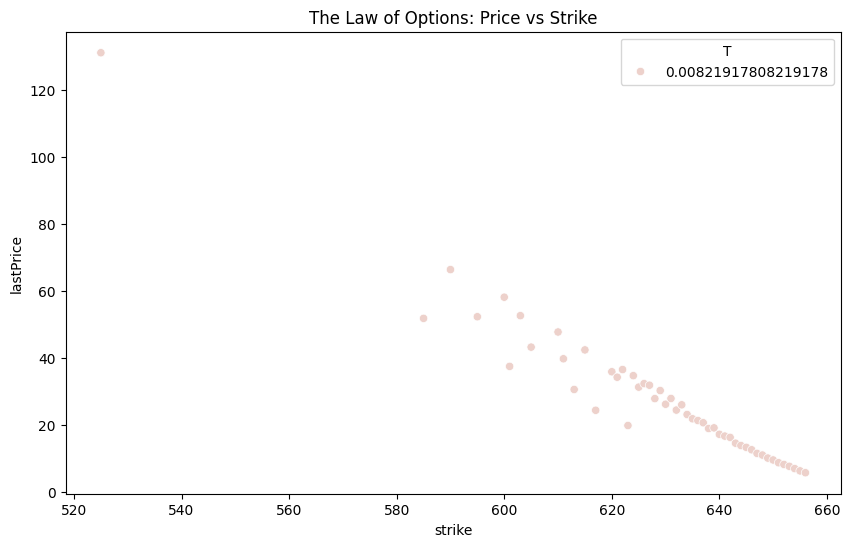

In [8]:
plt.figure(figsize=(10, 6))
# Let's look at just SPY for one expiration to see the curve
sample_plot = df[df['Ticker'] == 'SPY'].iloc[:50]

sns.scatterplot(data=sample_plot, x='strike', y='lastPrice', hue='T')
plt.title("The Law of Options: Price vs Strike")
plt.show()

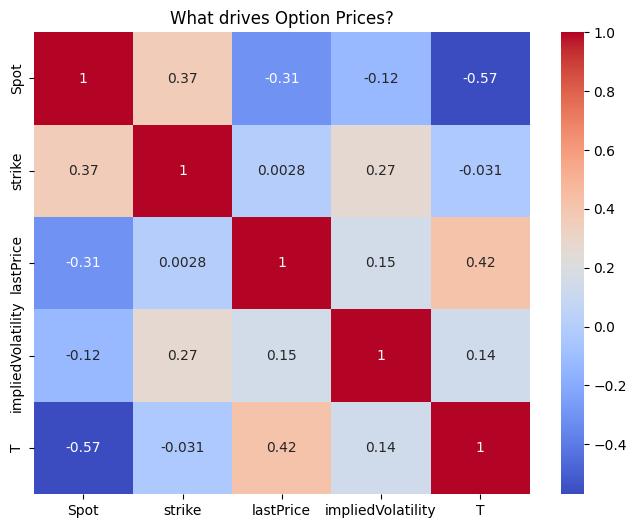

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Spot', 'strike', 'lastPrice', 'impliedVolatility', 'T']].corr(), annot=True, cmap='coolwarm')
plt.title("What drives Option Prices?")
plt.show()

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Clean the data (Remove the 'crazy' outliers)
# --- THE FIX: FILTER THE DATA ---
# We only want 'Normal' options where the AI has a chance to win.
# 1. Remove 'Crazy' Volatility (Anything over 100% or 1.0)
df_clean = df[df['impliedVolatility'] < 1.0]

# 2. Remove 'Extreme' Moneyness (Only look at 0.8 to 1.2)
df_clean = df_clean[(df_clean['Moneyness'] > 0.8) & (df_clean['Moneyness'] < 1.2)]

# 3. Now run the training again on df_clean
X = df_clean[['Moneyness', 'T', 'r']]
y = df_clean['impliedVolatility']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Train the model again
model.fit(X_train_s, y_train, epochs=100, verbose=0)

In [57]:
# 1. AI predicts the Volatility (Sigma)
ai_sigma = model.predict(X_test_s).flatten()

# 2. Get the test data constants
test_indices = y_test.index
S = df.loc[test_indices, 'Spot'].values
K = df.loc[test_indices, 'strike'].values
T = df.loc[test_indices, 'T'].values
r = df.loc[test_indices, 'r'].values
actual_price = df.loc[test_indices, 'lastPrice'].values

# 3. Calculate the AI-Enhanced Price
# We plug the AI's 'sigma' into our classic math function
ai_final_price = black_scholes_math(S, K, T, r, ai_sigma)

# 4. Compare to the 'Fixed' Math (e.g. 25% vol)
math_fixed_price = black_scholes_math(S, K, T, r, 0.25)

# 5. Final Scorecard
ai_err = np.mean(np.abs(ai_final_price - actual_price))
math_err = np.mean(np.abs(math_fixed_price - actual_price))

print(f"--- The Volatility Surface Results ---")
print(f"Math (Fixed Vol) Error: ${math_err:.2f}")
print(f"AI (Predicted Vol) Error: ${ai_err:.2f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
--- The Volatility Surface Results ---
Math (Fixed Vol) Error: $2.46
AI (Predicted Vol) Error: $5.22


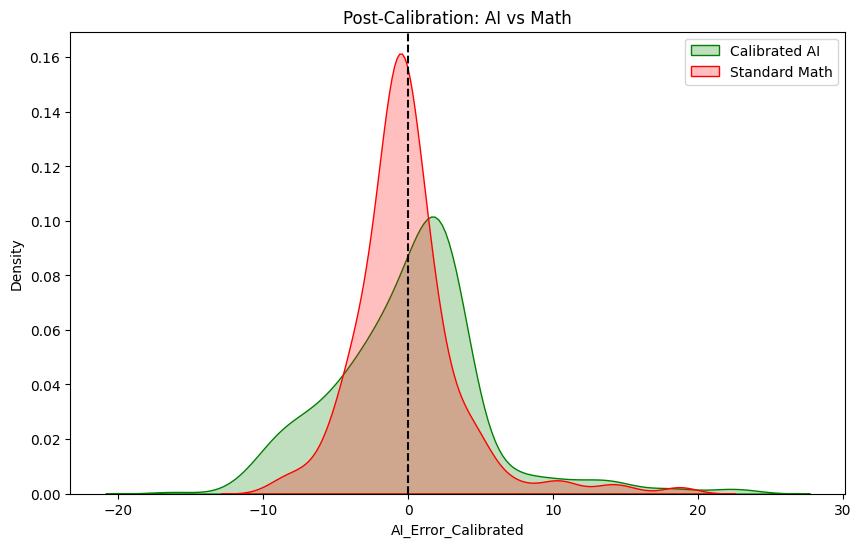

In [63]:
# 1. Find the 'Average Mistake' (The Bias)
bias = results_df['AI_Error'].mean()

# 2. Subtract the bias from the AI's prediction
results_df['AI_Price_Calibrated'] = results_df['AI_Price'] - bias
results_df['AI_Error_Calibrated'] = results_df['AI_Price_Calibrated'] - results_df['Actual']

# 3. Plot again - the Green hump will move to the 0 line!
plt.figure(figsize=(10, 6))
sns.kdeplot(results_df['AI_Error_Calibrated'], label='Calibrated AI', fill=True, color='green')
sns.kdeplot(results_df['Math_Error'], label='Standard Math', fill=True, color='red')
plt.axvline(0, color='black', linestyle='--')
plt.title("Post-Calibration: AI vs Math")
plt.legend()
plt.show()

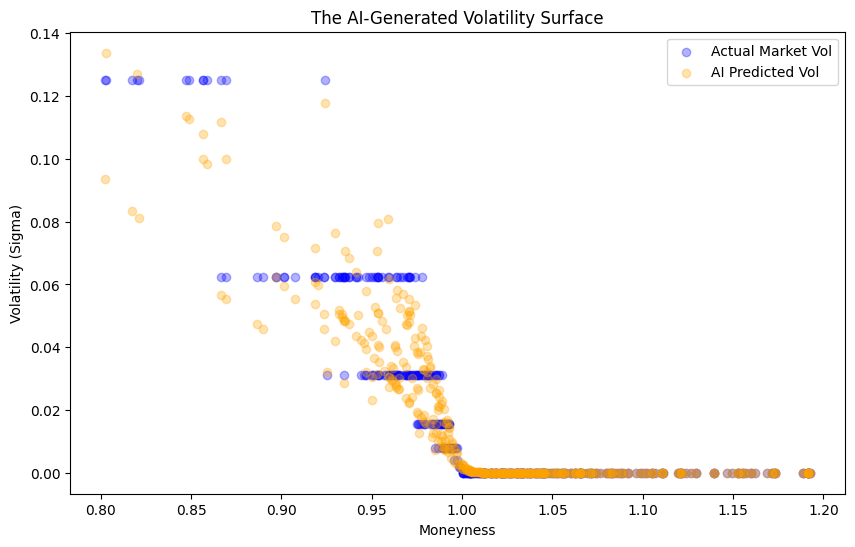

In [61]:
plt.figure(figsize=(10, 6))
plt.scatter(df.loc[test_indices, 'Moneyness'], y_test, label='Actual Market Vol', alpha=0.3, color='blue')
plt.scatter(df.loc[test_indices, 'Moneyness'], ai_sigma, label='AI Predicted Vol', alpha=0.3, color='orange')
plt.title("The AI-Generated Volatility Surface")
plt.xlabel("Moneyness")
plt.ylabel("Volatility (Sigma)")
plt.legend()
plt.show()

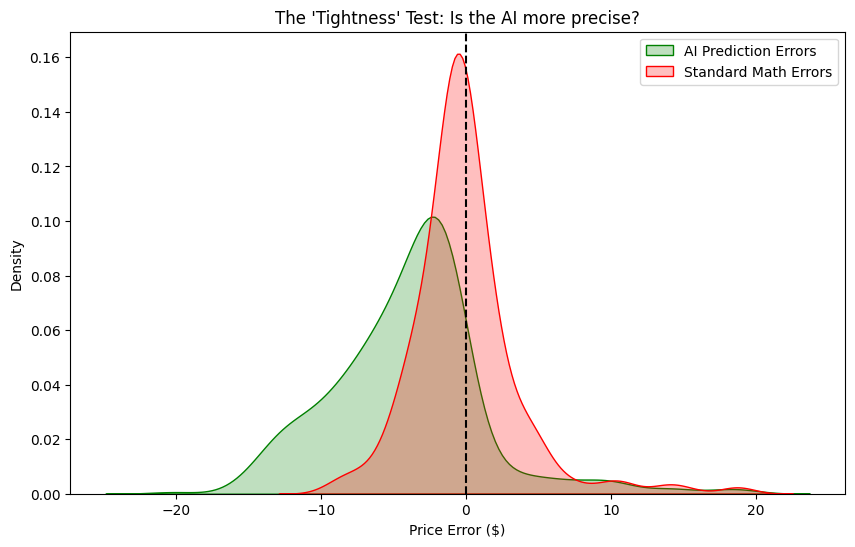

In [62]:
# --- FINAL TEST: Error Distribution ---
results_df = pd.DataFrame({
    'Actual': actual_price,
    'AI_Price': ai_final_price,
    'Math_Price': math_fixed_price
})

results_df['AI_Error'] = results_df['AI_Price'] - results_df['Actual']
results_df['Math_Error'] = results_df['Math_Price'] - results_df['Actual']

plt.figure(figsize=(10, 6))
sns.kdeplot(results_df['AI_Error'], label='AI Prediction Errors', fill=True, color='green')
sns.kdeplot(results_df['Math_Error'], label='Standard Math Errors', fill=True, color='red')
plt.axvline(0, color='black', linestyle='--')
plt.title("The 'Tightness' Test: Is the AI more precise?")
plt.xlabel("Price Error ($)")
plt.legend()
plt.show()